In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()


Saving Churn_Modelling.csv to Churn_Modelling (1).csv


In [ ]:
df = pd.read_csv("Churn_Modelling (1).csv")
print(df.head())


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [ ]:
print(df.shape)
print(df.isnull().sum())
print(f"Duplicates: {df.duplicated().sum()}")
print(df.dtypes)
df[['CreditScore','Age','Balance','EstimatedSalary']].describe()


(10000, 14)
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Duplicates: 0
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


,CreditScore,Age,Balance,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,76485.889288,100090.239881
std,96.653299,10.487806,62397.405202,57510.492818
min,350.000000,18.000000,0.000000,11.580000
25%,584.000000,32.000000,0.000000,51002.110000
50%,652.000000,37.000000,97198.540000,100193.915000
75%,718.000000,44.000000,127644.240000,149388.247500
max,850.000000,92.000000,250898.090000,199992.480000


In [ ]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print("Columns after cleaning:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")


Columns after cleaning:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Shape: (10000, 11)


In [ ]:
churn = df['Exited'].value_counts()
print(f"Stayed:  {churn[0]} ({churn[0]/len(df)*100:.1f}%)")
print(f"Churned: {churn[1]} ({churn[1]/len(df)*100:.1f}%)")

print(df.groupby('Geography')['Exited'].mean().round(3)*100)

print(df.groupby('Gender')['Exited'].mean().round(3)*100)

print(df.groupby('Exited')['Age'].mean().round(1))

Stayed:  7963 (79.6%)
Churned: 2037 (20.4%)
Geography
France     16.2
Germany    32.4
Spain      16.7
Name: Exited, dtype: float64
Gender
Female    25.1
Male      16.5
Name: Exited, dtype: float64
Exited
0    37.4
1    44.8
Name: Age, dtype: float64


In [ ]:
df.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


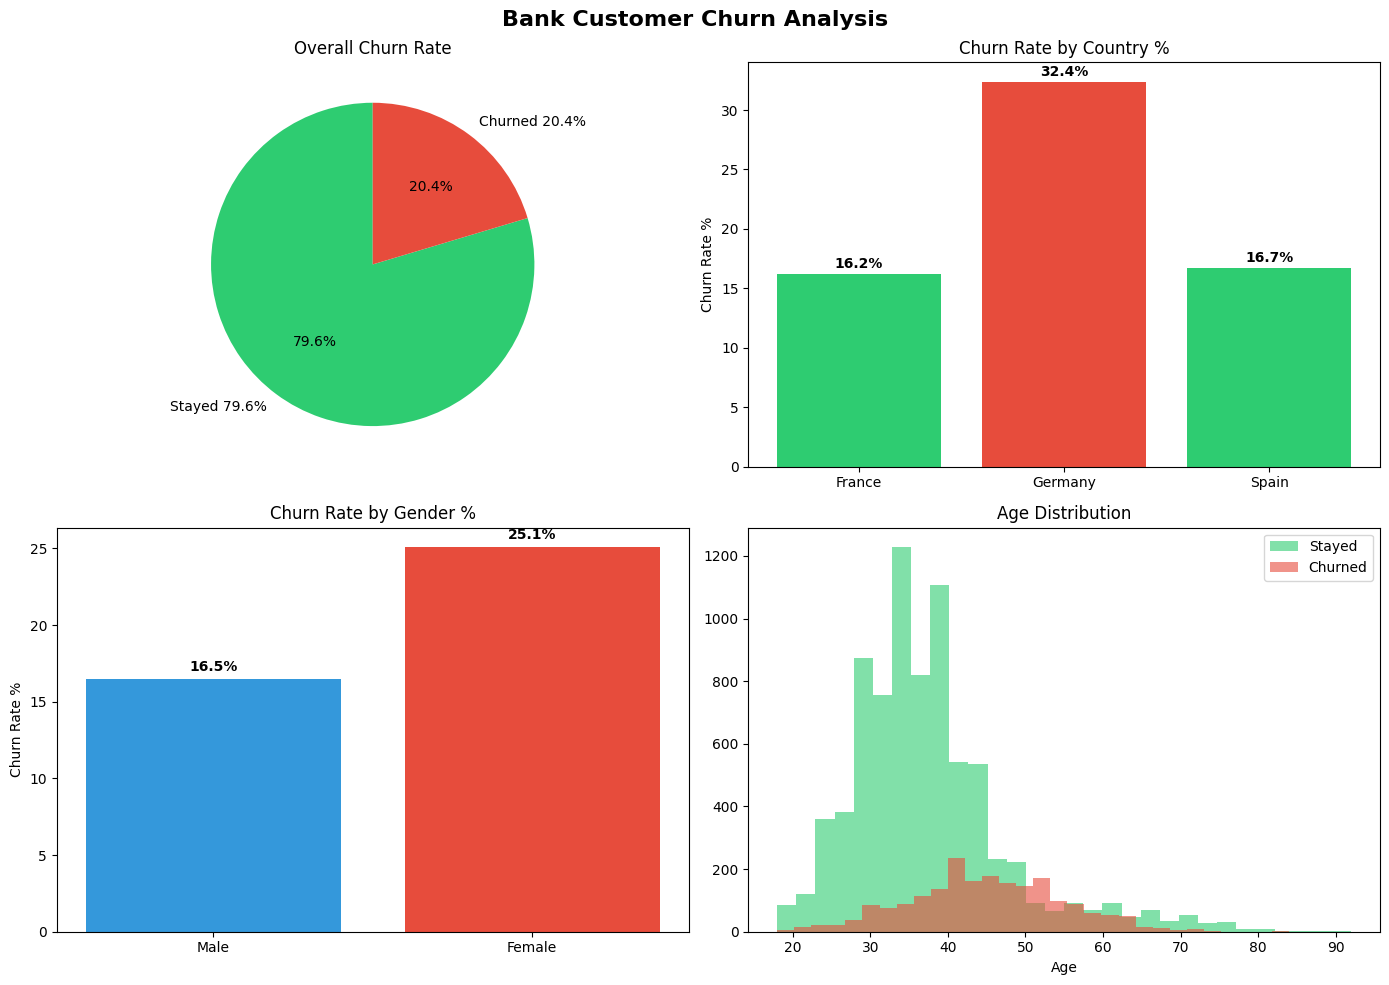

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bank Customer Churn Analysis",
             fontsize=16, fontweight="bold")

labels = ['Stayed 79.6%', 'Churned 20.4%']
sizes = [7963, 2037]
colors = ['#2ecc71', '#e74c3c']
axes[0,0].pie(sizes, labels=labels, colors=colors,
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title("Overall Churn Rate")

countries = ['France', 'Germany', 'Spain']
churn_rates = [16.2, 32.4, 16.7]
colors_c = ['#2ecc71', '#e74c3c', '#2ecc71']
axes[0,1].bar(countries, churn_rates, color=colors_c)
axes[0,1].set_title("Churn Rate by Country %")
axes[0,1].set_ylabel("Churn Rate %")
for i, v in enumerate(churn_rates):
    axes[0,1].text(i, v+0.5, f'{v}%',
                   ha='center', fontweight='bold')

genders = ['Male', 'Female']
churn_g = [16.5, 25.1]
colors_g = ['#3498db', '#e74c3c']
axes[1,0].bar(genders, churn_g, color=colors_g)
axes[1,0].set_title("Churn Rate by Gender %")
axes[1,0].set_ylabel("Churn Rate %")
for i, v in enumerate(churn_g):
    axes[1,0].text(i, v+0.5, f'{v}%',
                   ha='center', fontweight='bold')

churned = df[df['Exited']==1]['Age']
stayed = df[df['Exited']==0]['Age']
axes[1,1].hist(stayed, bins=30, alpha=0.6,
               color='#2ecc71', label='Stayed')
axes[1,1].hist(churned, bins=30, alpha=0.6,
               color='#e74c3c', label='Churned')
axes[1,1].set_title("Age Distribution")
axes[1,1].set_xlabel("Age")
axes[1,1].legend()

plt.tight_layout()
plt.show()




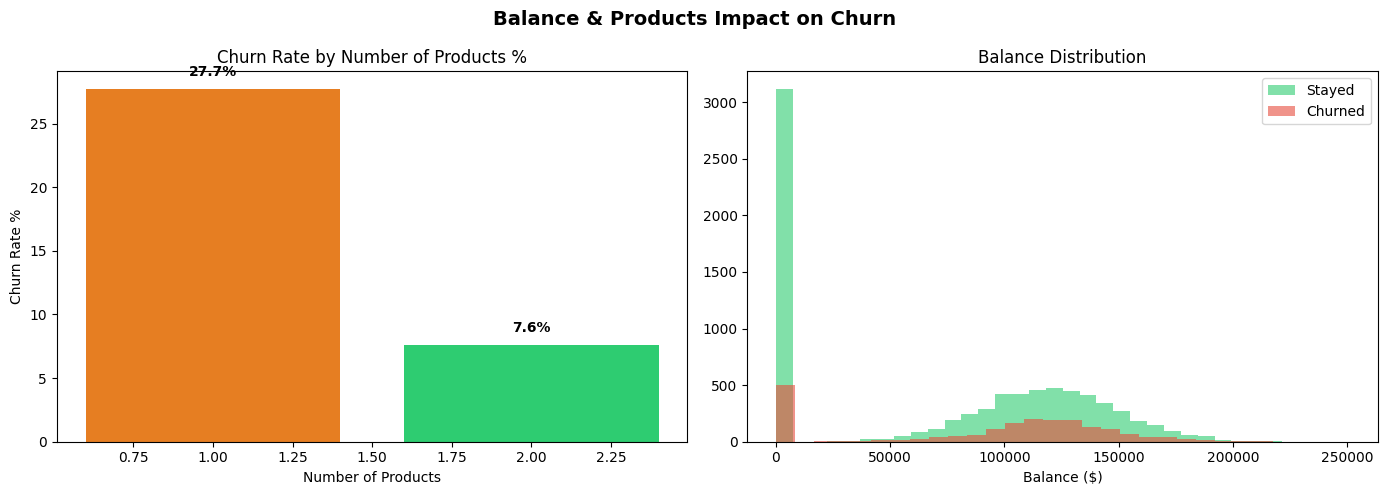

=== Churn by Active Member ===
Active Members:     14.3%
Non-Active Members: 26.9%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Balance & Products Impact on Churn",
             fontsize=14, fontweight="bold")

# Chart 1: فقط 1 و 2 products
products = df.groupby('NumOfProducts')['Exited'].mean() * 100
products = products[products.index <= 2]  # احذف 3 و 4
axes[0].bar(products.index, products.values,
            color=['#e67e22','#2ecc71'])
axes[0].set_title("Churn Rate by Number of Products %")
axes[0].set_xlabel("Number of Products")
axes[0].set_ylabel("Churn Rate %")
for i, v in enumerate(products.values):
    axes[0].text(products.index[i], v+1,
                 f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 2: Balance Distribution
churned_bal = df[df['Exited']==1]['Balance']
stayed_bal = df[df['Exited']==0]['Balance']
axes[1].hist(stayed_bal, bins=30, alpha=0.6,
             color='#2ecc71', label='Stayed')
axes[1].hist(churned_bal, bins=30, alpha=0.6,
             color='#e74c3c', label='Churned')
axes[1].set_title("Balance Distribution")
axes[1].set_xlabel("Balance ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("=== Churn by Active Member ===")
active = df.groupby('IsActiveMember')['Exited'].mean()*100
print(f"Active Members:     {active[1]:.1f}%")
print(f"Non-Active Members: {active[0]:.1f}%")

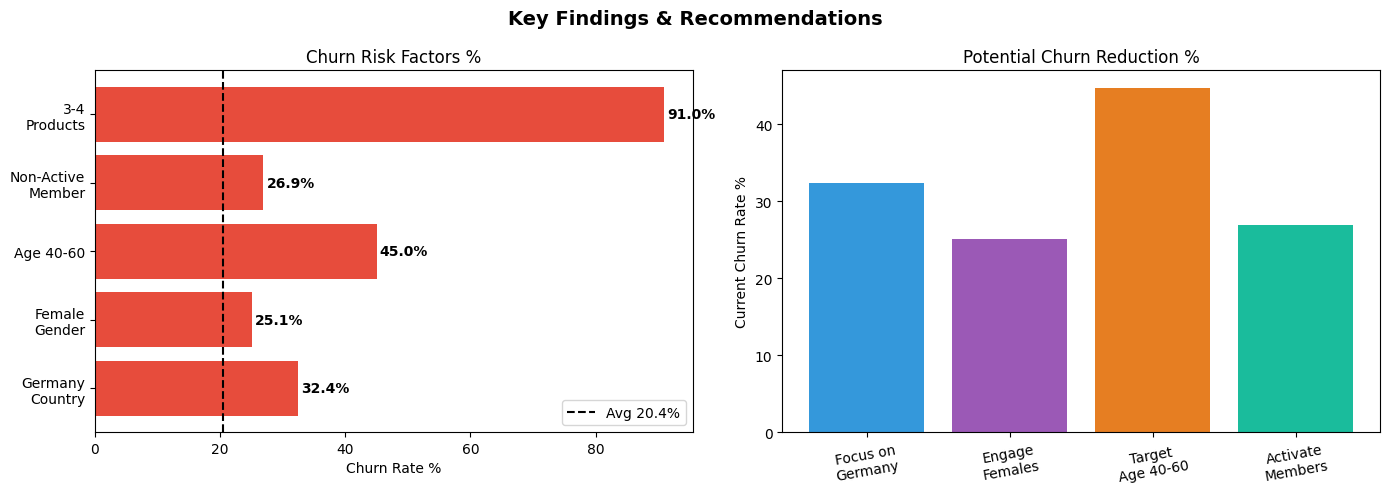

=== TOP 3 RECOMMENDATIONS ===
1. Focus retention efforts on Germany (32.4% churn)
2. Re-engage non-active members (26.9% churn)
3. Investigate why Age 40-60 churns more (45.0%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Key Findings & Recommendations",
             fontsize=14, fontweight="bold")

# Chart 1: Summary of Risk Factors
factors = ['Germany\nCountry', 'Female\nGender',
           'Age 40-60', 'Non-Active\nMember',
           '3-4\nProducts']
risk = [32.4, 25.1, 45.0, 26.9, 91.0]
colors = ['#e74c3c' if r > 25 else '#e67e22' for r in risk]
axes[0].barh(factors, risk, color=colors)
axes[0].set_title("Churn Risk Factors %")
axes[0].set_xlabel("Churn Rate %")
axes[0].axvline(x=20.4, color='black',
                linestyle='--', label='Avg 20.4%')
axes[0].legend()
for i, v in enumerate(risk):
    axes[0].text(v+0.5, i, f'{v}%',
                 va='center', fontweight='bold')

# Chart 2: Recommendations Impact (بدون Limit to 2 Products)
recs = ['Focus on\nGermany', 'Engage\nFemales',
        'Target\nAge 40-60', 'Activate\nMembers']
impact = [32.4, 25.1, 44.8, 26.9]
axes[1].bar(recs, impact,
            color=['#3498db','#9b59b6','#e67e22','#1abc9c'])
axes[1].set_title("Potential Churn Reduction %")
axes[1].set_ylabel("Current Churn Rate %")
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

print("=== TOP 3 RECOMMENDATIONS ===")
print("1. Focus retention efforts on Germany (32.4% churn)")
print("2. Re-engage non-active members (26.9% churn)")
print("3. Investigate why Age 40-60 churns more (45.0%)")